In [12]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

# 6.03 — Paper figures: prior integration on the shared GLM-HMM basis

A single **K-robust, interpretable** index instead of 'occupancy of a labelled state'.

**Prior-integration index** (per session): the model-predicted shift in P(right) at zero
coherence induced by the informative prior,

  prior_bias = Σ_k occ_k·σ(bias_k + color_k)  −  Σ_k occ_k·σ(bias_k)

It sums over **all** states, so it is **permutation-invariant and K-independent** (no
alignment, no 'which is the color state'), and it is in **probability units** — directly
comparable to the behavioural prior shift. Story: (1) a state dictionary, (2) the
medication effect on the index, (3) validation against model-free behaviour.

In [13]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, pearsonr
from scipy.optimize import linear_sum_assignment

from imports import *
from config import dir_config
from src.shared_glm_hmm.grouping import session_metadata

def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))

In [14]:
processed_dir = Path(dir_config.data.processed)

metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")
sess_md = session_metadata(metadata).set_index("session_id")

experiment = "XY__tgt"

In [15]:
final_path = processed_dir / "shared_glm_hmm" / experiment / "all_subjects_final.pkl"
cv_path = processed_dir / "shared_glm_hmm" / experiment / "all_subjects.pkl"
bundle = pickle.load(open(final_path, "rb"))
pooled = bundle["model"]["pooled"]
sess_models = bundle["model"]["models"]
data   = bundle["data"]
feats  = bundle["config"]["model_features"]
K      = bundle["best_k"]
ci, bi = feats.index("color"), feats.index("bias")
si = feats.index("stimulus")

# model-free behavioral prior shift (available for all 100 sessions)
beh = metadata.drop_duplicates("session_id").set_index("session_id")[["positive_bias", "equal_bias"]]
beh["beh_prior_shift"] = beh["positive_bias"] - beh["equal_bias"]
print(f"CONFIG={experiment}  K={K}  n_sessions={len(data)}  features={feats}")

CONFIG=XY__tgt  K=4  n_sessions=100  features=['stimulus', 'color', 'bias', 'prev_choice_1', 'prev_target_1', 'prev_choice_target_1']


In [16]:
def get_state_colors(Kn):
    return [STATE_COLORS[k % len(STATE_COLORS)] for k in range(Kn)]


def state_label(k):
    return f"State {k + 1}"


def _align(w, ref):
    cost = np.array([[np.sum((w[i] - ref[j]) ** 2) for j in range(len(ref))] for i in range(len(w))])
    _, col = linear_sum_assignment(cost)
    inv = np.empty_like(col)
    inv[col] = np.arange(len(col))
    return inv


def get_session_color(sid, n_back):
    """Per-trial color for one session, trimmed to match the bundle (process_sessions logic)."""
    td = behavior_df[behavior_df["session_id"] == sid].reset_index(drop=True)
    valid_idx = np.where(td["outcome"].values != -1)[0]
    first_trial = valid_idx[n_back - 1] + 1
    return td["color"].values[first_trial:]


def build_group_data(bundle, sess_md):
    """{group_tuple: {session_weights, session_occupancy, session_predicted_dfs}} on shared basis."""
    ref_w = -bundle["model"]["pooled"].observations.params[:, 0, :]  # (K, M) this run's shared basis
    n_back = bundle["config"].get("n_trials_back", 1)
    groups = {}
    for sid, m in bundle["model"]["models"].items():
        if sid not in sess_md.index:
            continue
        g = (sess_md.loc[sid, "subtype"], sess_md.loc[sid, "medication"])
        df = bundle["data"][sid]
        X = df[feats].values.astype(float)
        y = df["choices"].values.astype(int).reshape(-1, 1)
        msk = df["mask"].values.astype(bool).reshape(-1, 1)
        post = m.expected_states(data=y, input=X, mask=msk)[0]  # (T, K)
        w = -m.observations.params[:, 0, :]
        perm = _align(w, ref_w)
        valid = msk[:, 0]
        # expected choice prob (permutation-invariant)
        wsum = np.einsum("tm,km->tk", X, w)
        sig = 1 / (1 + np.exp(-wsum))
        ecp = (sig * post).sum(1)
        color_raw = df["color"].values if "color" in df.columns else get_session_color(sid, n_back)
        pdf = pd.DataFrame(
            {
                "stimulus": df["stimulus"].values[valid],
                "choices": y[valid, 0],
                "color": (color_raw[valid] > 0).astype(int),  # equal=0, unequal=1
                "expected_choice_prob": np.clip(ecp[valid], 1e-6, 1 - 1e-6),
            }
        )
        gd = groups.setdefault(g, {"session_weights": {}, "session_occupancy": {}, "session_predicted_dfs": {}})
        gd["session_weights"][sid] = w[perm]
        gd["session_occupancy"][sid] = post[:, perm][valid].mean(0)
        gd["session_predicted_dfs"][sid] = pdf
    return groups


def compute_group_psychometrics(predicted_dfs):
    conditions = [(0, "Equal", "gray"), (1, "Unequal", "black")]
    result = {}
    for cval, label, color in conditions:
        actual, model = [], []
        x_bins = x_hat = None
        for pdf in predicted_dfs.values():
            sub = pdf[pdf["color"] == cval]
            if len(sub) < 5:
                continue
            stim = sub["stimulus"].to_numpy() * 100
            ch = sub["choices"].values.astype(int)
            ep = sub["expected_choice_prob"].values
            try:
                xd, yd, _, xh, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": ch})
                actual.append(yd)
                if x_bins is None:
                    x_bins, x_hat = xd, xh
                _, ym, _, _, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": npr.binomial(1, ep)})
                model.append(ym)
            except Exception:
                continue
        if not actual:
            continue
        ya, ym = np.array(actual), np.array(model)
        S = len(actual)

        def safe_fit(y):
            try:
                return pmf_utils.fit_psychometric_function(x_bins, y, trial_counts=None, model_type="logit_4").predict(x_hat)
            except Exception:
                return None

        result[cval] = dict(
            label=label,
            color=color,
            x_bins=x_bins,
            x_hat=x_hat,
            actual=actual,
            model=model,
            mean_actual=ya.mean(0),
            sem_actual=ya.std(0) / np.sqrt(S),
            mean_model=ym.mean(0),
            sem_model=ym.std(0) / np.sqrt(S),
            fit_actual=safe_fit(ya.mean(0)),
            fit_model=safe_fit(ym.mean(0)),
        )
    return result


def plot_color_psych(ax, gp, mode, title=""):
    for cval in sorted(gp):
        c = gp[cval]
        col = c["color"]
        for ys in c[mode]:
            ax.plot(c["x_bins"], ys, "o-", color=col, alpha=0.08, lw=0.8, ms=3)
        ax.errorbar(c["x_bins"], c[f"mean_{mode}"], yerr=c[f"sem_{mode}"], color=col, marker="o", ms=9, mec="k", ls="", label=c["label"], elinewidth=2, capsize=7)
        if c[f"fit_{mode}"] is not None:
            ax.plot(c["x_hat"], c[f"fit_{mode}"], color=col, ls="-", lw=2.5)
    ax.axhline(0.5, color="k", ls=":", lw=0.8)
    ax.set(xlabel="Coherence (%)", ylabel="P(right)", xlim=(-105, 105), ylim=(-0.05, 1.05), xticks=[-100, -35, -13, 0, 13, 35, 100], title=title)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)


def plot_group_row(axrow, group, gd):
    label = GROUP_LABELS.get(group, str(group))
    colors = get_state_colors(K)
    ax_beh, ax_mdl, ax_psych, ax_w, ax_occ = axrow
    gp = compute_group_psychometrics(gd["session_predicted_dfs"])
    plot_color_psych(ax_beh, gp, "actual", f"{label} \u2014 Behavior")
    plot_color_psych(ax_mdl, gp, "model", f"{label} \u2014 GLM-HMM")

    Wg = np.stack(list(gd["session_weights"].values()))
    S = len(Wg)
    Og = np.stack(list(gd["session_occupancy"].values()))
    mean_w, sem_w = Wg.mean(0), Wg.std(0) / np.sqrt(S)
    mean_o, sem_o = Og.mean(0), Og.std(0) / np.sqrt(S)

    si = feats.index("stimulus") if "stimulus" in feats else 0
    bi = feats.index("bias") if "bias" in feats else None

    ci = next((i for i, f in enumerate(feats) if f == "color"), None)
    cXs_i = next((i for i, f in enumerate(feats) if "color" in f and "stim" in f.lower()), None)

    xr = np.linspace(-1, 1, 200)

    for k in range(K):
        for c in [0, 1]:
            logit = mean_w[k, si] * xr
            if bi is not None:
                logit += mean_w[k, bi]
            if ci is not None:
                logit += mean_w[k, ci] * c
            if cXs_i is not None:
                logit += mean_w[k, cXs_i] * xr * c

            ax_psych.plot(xr * 100, 1 / (1 + np.exp(-logit)), color=colors[k], lw=2, label=state_label(k))
    ax_psych.axhline(0.5, color="k", ls=":", lw=0.8)
    ax_psych.set(xlabel="Coherence (%)", ylabel="P(right)", ylim=(0, 1), title=f"{label} \u2014 states")
    ax_psych.legend(fontsize=7)

    xf = np.arange(len(feats))
    for k in range(K):
        ax_w.errorbar(xf, mean_w[k], yerr=sem_w[k], color=colors[k], marker="o", lw=1.4, capsize=3, label=state_label(k))
    ax_w.axhline(0, color="k", ls="--", lw=0.8)
    ax_w.set_xticks(xf)
    ax_w.set_xticklabels(feats, rotation=20, ha="right", fontsize=8)
    ax_w.set(ylabel="GLM weight", title="Weights (mean \u00b1 SEM)")
    ax_w.legend(fontsize=7)

    xk = np.arange(K)
    ax_occ.bar(xk, mean_o, color=colors, alpha=0.85, yerr=sem_o, capsize=4)
    for k in range(K):
        ax_occ.scatter(np.full(S, k) + np.random.uniform(-0.15, 0.15, S), Og[:, k], color=colors[k], s=10, alpha=0.5, zorder=3)
    ax_occ.set_xticks(xk)
    ax_occ.set_xticklabels([f"S{k + 1}" for k in range(K)])
    ax_occ.set(ylabel="Occupancy", ylim=(0, 1), title="State occupancy")


## 0. Group Plots

NameError: name 'GROUP_LABELS' is not defined

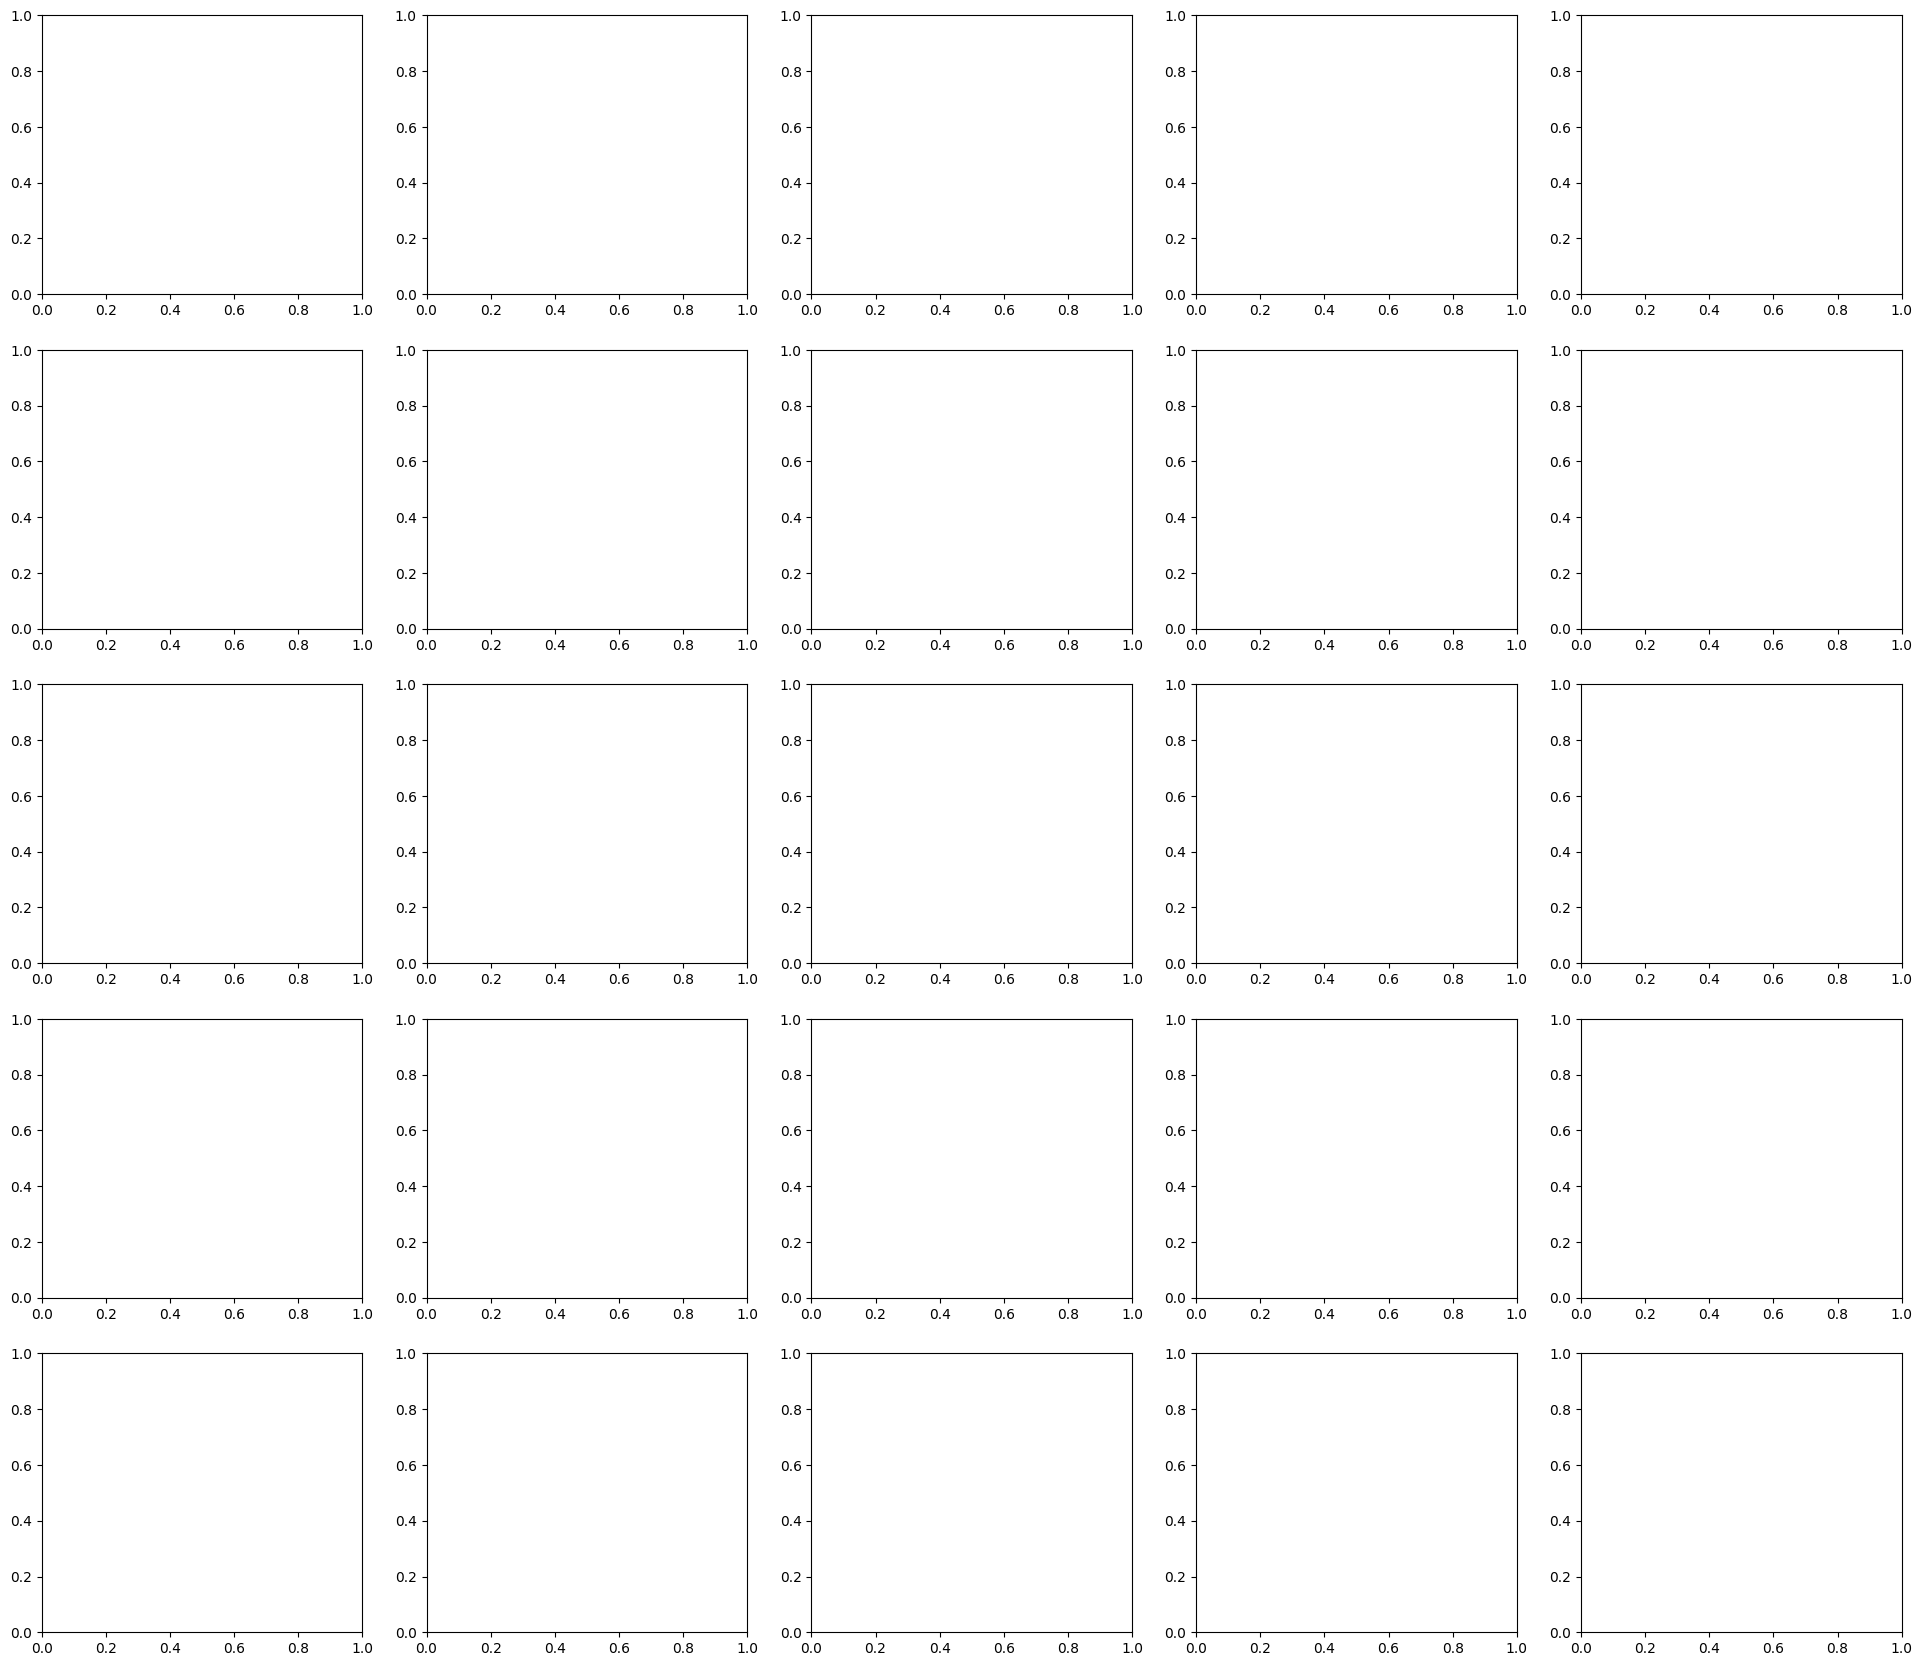

In [17]:
group_data = build_group_data(bundle, sess_md)
GROUP_ORDER = [("HC","none"), ("tremor","off"), ("tremor","on"),
               ("bradykinetic","off"), ("bradykinetic","on")]
GROUP_ORDER = [g for g in GROUP_ORDER if g in group_data]

nG = len(GROUP_ORDER)
fig, axes = plt.subplots(nG, 5, figsize=(24, 4.2*nG), squeeze=False)
for row, g in enumerate(GROUP_ORDER):
    plot_group_row(axes[row], g, group_data[g])
fig.suptitle(f"{experiment} \u2014 per-group panels (shared basis)", fontsize=15, y=1.005)
plt.tight_layout(); plt.show()

## 1. State dictionary (shared pooled basis)

The K states, named by their weight profile: **Engaged** (max stimulus), **Prior** (max
color), **Lapse** (min stimulus), others **History/bias**. Shown once — the common basis
every session is scored against.

In [18]:
Wp = -pooled.observations.params[:, 0, :]      # (K, M)
idx_eng   = int(np.argmax(Wp[:, si]))
idx_prior = int(np.argmax(Wp[:, ci]))
idx_lapse = int(np.argmin(Wp[:, si]))
names = {}
for k in range(K):
    if k == idx_eng:     names[k] = "Engaged"
    elif k == idx_prior: names[k] = "Prior"
    elif k == idx_lapse: names[k] = "Lapse"
    else:                names[k] = "History/bias"
STATE_COLORS = ["#377eb8", "#e41a1c", "#4daf4a", "#984ea3", "#ff7f00", "#a65628", "#999999"]

wtab = pd.DataFrame(Wp, columns=feats, index=[f"S{k} ({names[k]})" for k in range(K)])
print("State GLM weights (shared pooled basis):")
wtab.round(3)

State GLM weights (shared pooled basis):


,stimulus,color,bias,prev_choice_1,prev_target_1,prev_choice_target_1
S0 (History/bias),3.000,0.038,0.629,0.114,0.379,-0.097
S1 (Prior),2.956,0.334,-0.578,-0.043,0.189,0.025
S2 (Engaged),7.900,0.283,-0.107,-0.001,0.116,-0.086
S3 (Lapse),0.702,0.169,0.017,0.013,0.511,0.031


NameError: name 'CONFIG' is not defined

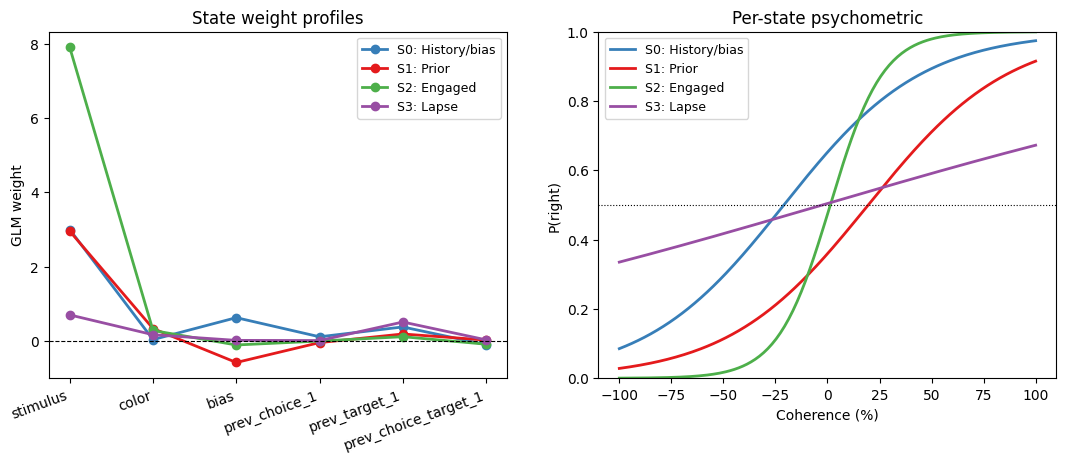

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(feats))
for k in range(K):
    axes[0].plot(x, Wp[k], marker="o", lw=2, color=STATE_COLORS[k % len(STATE_COLORS)],
                 label=f"S{k}: {names[k]}")
axes[0].axhline(0, color="k", ls="--", lw=0.8); axes[0].set_xticks(x)
axes[0].set_xticklabels(feats, rotation=20, ha="right"); axes[0].set_ylabel("GLM weight")
axes[0].set_title("State weight profiles"); axes[0].legend(fontsize=9)

stim = np.linspace(-1, 1, 200)
for k in range(K):
    axes[1].plot(stim * 100, sigmoid(Wp[k, si] * stim + Wp[k, bi]),
                 lw=2, color=STATE_COLORS[k % len(STATE_COLORS)], label=f"S{k}: {names[k]}")
axes[1].axhline(0.5, color="k", ls=":", lw=0.8)
axes[1].set(xlabel="Coherence (%)", ylabel="P(right)", ylim=(0, 1), title="Per-state psychometric")
axes[1].legend(fontsize=9)
fig.suptitle(f"{CONFIG} — state dictionary (K={K})", fontsize=14)
plt.tight_layout(); plt.show()

## 2. Prior-integration index per session

Permutation-invariant (sum over states) → no alignment, K-robust. Reported in probability
units (prior-induced P(right) shift at zero coherence).

In [ ]:
def prior_index(model, df):
    X = df[feats].values.astype(float)
    y = df["choices"].values.astype(int).reshape(-1, 1)
    m = df["mask"].values.astype(bool).reshape(-1, 1)
    occ = model.expected_states(data=y, input=X, mask=m)[0][m[:, 0]].mean(0)   # (K,)
    W = -model.observations.params[:, 0, :]
    wb, wc = W[:, bi], W[:, ci]
    p_eq   = np.sum(occ * sigmoid(wb))
    p_uneq = np.sum(occ * sigmoid(wb + wc))
    return p_uneq - p_eq, float(np.sum(occ * wc))   # (prob-shift, logit w_eff)

rows = []
for sid, m in sess_models.items():
    pb, weff = prior_index(m, data[sid])
    rows.append(dict(session_id=sid, prior_bias=pb, w_eff=weff))
idx_df = pd.DataFrame(rows).set_index("session_id").join(sess_md).join(beh["beh_prior_shift"])
idx_df["subtype"] = pd.Categorical(idx_df["subtype"], ["HC","tremor","bradykinetic","intermediate"])
print("prior-integration index table:", idx_df.shape)
idx_df.groupby(["subtype","medication"], observed=True)["prior_bias"].agg(["mean","sem","count"]).round(3)

prior-integration index table: (100, 7)


mean    sem  count
subtype      medication                     
HC           none        0.103  0.033     18
tremor       off         0.014  0.046     11
             on          0.133  0.038     11
bradykinetic off         0.056  0.042     10
             on          0.053  0.042     10
intermediate off         0.267    NaN      1
             on         -0.086    NaN      1

## 3. Medication effect on prior integration (within-subject)

In [ ]:
pdx = idx_df[idx_df["is_pd"] == 1]
paired = (pdx.pivot_table(index=["subject_id","subtype"], columns="medication",
                          values="prior_bias", observed=True)
         .dropna(subset=["off","on"]).reset_index())

def test(sub):
    d = paired if sub is None else paired[paired["subtype"] == sub]
    if len(d) < 3: return dict(group=sub or "all_PD", n=len(d), off=np.nan, on=np.nan, delta=np.nan, p=np.nan)
    _, p = wilcoxon(d["off"], d["on"])
    return dict(group=sub or "all_PD", n=len(d), off=d["off"].mean(), on=d["on"].mean(),
                delta=(d["on"]-d["off"]).mean(), p=p)

res = pd.DataFrame([test(s) for s in [None, "tremor", "bradykinetic"]])
print("Paired Wilcoxon: OFF vs ON prior-integration index (prob units)")
res.round(4)

Paired Wilcoxon: OFF vs ON prior-integration index (prob units)


,group,n,off,on,delta,p
0,all_PD,22,0.0445,0.0866,0.0421,0.3705
1,tremor,11,0.0136,0.1326,0.1189,0.0830
2,bradykinetic,10,0.0561,0.0532,-0.0029,1.0000


## 4. Figure — prior integration per group + within-subject OFF→ON

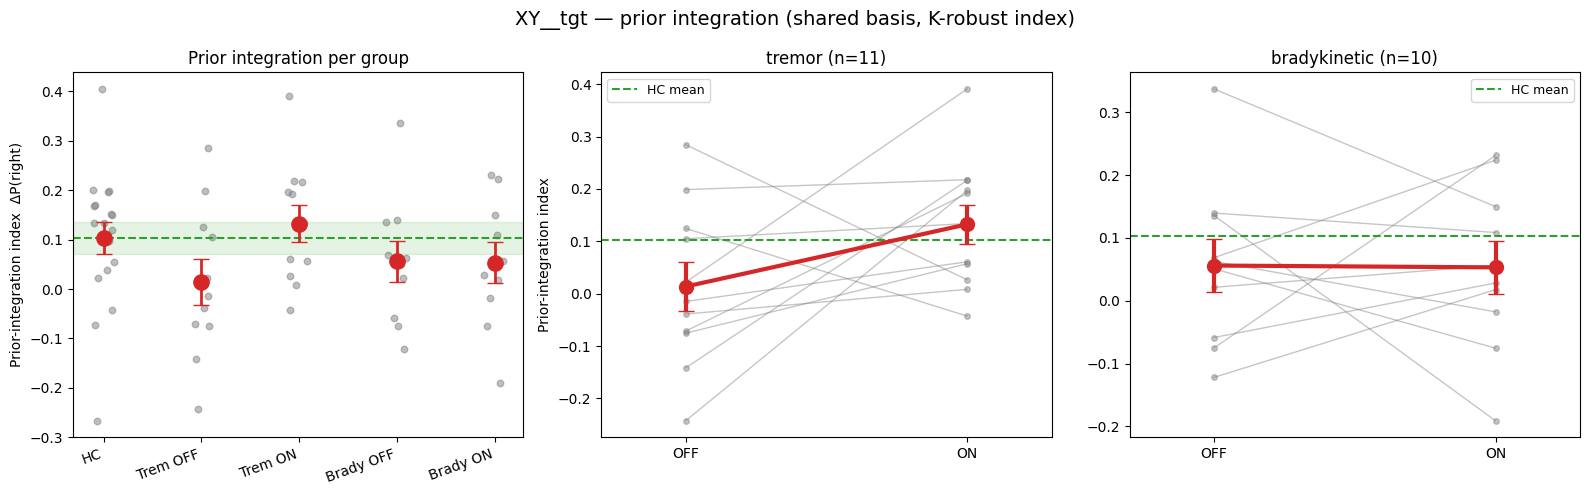

In [ ]:
GROUPS = [("HC","none"),("tremor","off"),("tremor","on"),("bradykinetic","off"),("bradykinetic","on")]
GROUPS = [g for g in GROUPS if g in set(map(tuple, idx_df[["subtype","medication"]].values))]
glab = {("HC","none"):"HC",("tremor","off"):"Trem OFF",("tremor","on"):"Trem ON",
        ("bradykinetic","off"):"Brady OFF",("bradykinetic","on"):"Brady ON"}
hc = idx_df[idx_df["subtype"]=="HC"]["prior_bias"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
for i, g in enumerate(GROUPS):
    v = idx_df[(idx_df["subtype"]==g[0]) & (idx_df["medication"]==g[1])]["prior_bias"]
    ax.scatter(np.full(len(v), i)+np.random.uniform(-0.12,0.12,len(v)), v, color="gray", alpha=0.5, s=22)
    ax.errorbar(i, v.mean(), yerr=v.sem(), color="tab:red", marker="o", ms=11, capsize=6, lw=2, zorder=5)
ax.axhspan(hc.mean()-hc.sem(), hc.mean()+hc.sem(), color="tab:green", alpha=0.12)
ax.axhline(hc.mean(), color="tab:green", ls="--", lw=1.5)
ax.set_xticks(range(len(GROUPS))); ax.set_xticklabels([glab[g] for g in GROUPS], rotation=20, ha="right")
ax.set(ylabel="Prior-integration index  \u0394P(right)", title="Prior integration per group")

for ax, sub in zip(axes[1:], ["tremor","bradykinetic"]):
    d = paired[paired["subtype"]==sub]
    for _, r in d.iterrows():
        ax.plot([0,1],[r["off"],r["on"]], "-o", color="gray", alpha=0.45, lw=1, ms=4)
    ax.errorbar([0,1],[d["off"].mean(),d["on"].mean()], yerr=[d["off"].sem(),d["on"].sem()],
                color="tab:red", lw=3, marker="o", ms=10, capsize=6, zorder=5)
    ax.axhline(hc.mean(), color="tab:green", ls="--", lw=1.5, label="HC mean")
    ax.set_xticks([0,1]); ax.set_xticklabels(["OFF","ON"]); ax.set_xlim(-0.3,1.3)
    ax.set_title(f"{sub} (n={len(d)})"); ax.legend(fontsize=9)
axes[1].set_ylabel("Prior-integration index")
fig.suptitle(f"{CONFIG} — prior integration (shared basis, K-robust index)", fontsize=14)
plt.tight_layout(); plt.show()

## 5. Validation — GLM-HMM index vs model-free behaviour

If the latent index means what we claim, it should track the behavioural prior shift
(equal vs unequal psychometric bias) across sessions.

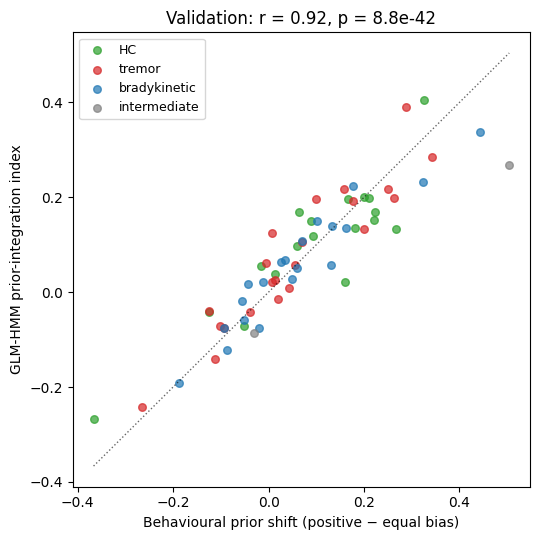

In [ ]:
d = idx_df.dropna(subset=["prior_bias","beh_prior_shift"])
r, p = pearsonr(d["prior_bias"], d["beh_prior_shift"])
cmap = {"HC":"tab:green","tremor":"tab:red","bradykinetic":"tab:blue","intermediate":"gray"}
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for sub, dd in d.groupby("subtype", observed=True):
    ax.scatter(dd["beh_prior_shift"], dd["prior_bias"], s=30, alpha=0.7, color=cmap.get(sub,"gray"), label=sub)
lims = [min(d["beh_prior_shift"].min(), d["prior_bias"].min()), max(d["beh_prior_shift"].max(), d["prior_bias"].max())]
ax.plot(lims, lims, "k:", lw=1, alpha=0.6)
ax.set(xlabel="Behavioural prior shift (positive − equal bias)", ylabel="GLM-HMM prior-integration index",
       title=f"Validation: r = {r:.2f}, p = {p:.1e}")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## 6. Robustness — the index is stable across K

Recompute the tremor OFF→ON effect using the pooled global model at each K (from the CV
bundle). The index is permutation-invariant, so the medication effect should hold
regardless of the chosen state count — removing the K-fragility concern.

In [ ]:
cvb = pickle.load(open(cv_path, "rb"))
gmods, glls = cvb["global"]["models"], cvb["global"]["fits_lls"]

def best_global(Kk):
    lls = [ll[-1] if np.ndim(ll) else float(ll) for ll in glls[Kk]]
    return gmods[Kk][int(np.argmax(lls))]

rob = []
for Kk in sorted(int(k) for k in gmods):
    if Kk < 2:
        continue
    gm = best_global(Kk)
    pb = {sid: prior_index(gm, df)[0] for sid, df in data.items()}
    s = pd.DataFrame({"prior_bias": pb}).join(sess_md)
    tre = s[s["subtype"] == "tremor"]
    piv = tre.pivot_table(index="subject_id", columns="medication", values="prior_bias")
    piv = piv.dropna(subset=["off", "on"]) if {"off", "on"} <= set(piv.columns) else piv.iloc[0:0]
    if len(piv) >= 3:
        _, pval = wilcoxon(piv["off"], piv["on"]); delta = (piv["on"] - piv["off"]).mean()
    else:
        pval, delta = np.nan, np.nan
    rob.append(dict(K=Kk, tremor_delta=delta, tremor_p=pval, n=len(piv)))

rob_df = pd.DataFrame(rob)
print("Tremor OFF\u2192ON prior-index effect across K (global pooled models):")
rob_df.round(4)

Tremor OFF→ON prior-index effect across K (global pooled models):


,K,tremor_delta,tremor_p,n
0,2,0.0006,0.9658,11
1,3,0.0057,0.5195,11
2,4,0.0009,0.8311,11
3,5,0.0069,0.5771,11
4,6,0.0227,0.3203,11
